# Notebook 1 - Exploration

This notebook covers:

- Loaded and explored the real estate dataset.
- Reviewed data types, missing values, and overall data quality.
- Performed exploratory data analysis (EDA) using descriptive statistics and visualizations.
- Examined relationships between housing characteristics and sale prices.
- Identified preprocessing tasks for the next stage.

## Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from pathlib import Path

In [2]:
# Load csv files into dataframe
folder_path = Path("../data/raw")
csv_files = sorted(folder_path.glob("*.csv"))
raw_df_lst = []
for file in csv_files:
    temp_df = pd.read_csv(file, low_memory = False)
    raw_df_lst.append(temp_df)
raw_df = pd.concat(raw_df_lst, ignore_index = True)

## Raw Data Exploration

In [3]:
# Dataframe's structure
print(f"Loaded {len(raw_df)} rows and {len(raw_df.columns)} columns.")

Loaded 794271 rows and 82 columns.


In [4]:
# The first 10 rows of dataframe
raw_df.head(10)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,...,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,...,1.0,Apple Valley Unified,92308,0.0,43000.00,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,...,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,2.0,Carlsbad Unified,92008,140.0,13376.00,NaN,False,False,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,...,1.0,Other,95111,300.0,2738.00,NaN,False,False,NaN,NaN
5,NaN,True,NaN,NaN,NaN,1300000.0,556365287,deborah@donnerland.com,2022-02-18,1300000.0,...,NaN,Other,95006,NaN,2228834.52,NaN,False,False,NaN,NaN
6,NaN,True,NaN,NaN,False,565000.0,556365286,joseph@labelrealtygroup.com,2022-01-10,640000.0,...,1.0,Rim of the World,92352,0.0,3397.00,NaN,False,False,NaN,NaN
7,NaN,False,NaN,NaN,False,349999.0,556365284,eaguayo08@gmail.com,2022-03-23,438000.0,...,2.0,Fontana Unified,92336,0.0,9900.00,NaN,False,False,NaN,NaN
8,Carpet,False,NaN,NaN,True,325500.0,556364868,wspasiano@yahoo.com,2022-04-14,325000.0,...,1.0,NaN,93003,290.0,NaN,NaN,False,False,NaN,NaN
9,Laminate,False,NaN,NaN,False,219250.0,556364724,ashley@theashleycooperteam.com,2022-02-14,248000.0,...,1.0,Hemet Unified,92545,93.0,1307.00,NaN,False,False,NaN,NaN


In [5]:
# Basic information of dataframe
object_cols = raw_df.select_dtypes(include = "object").columns
raw_df[object_cols] = raw_df[object_cols].astype("string")
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794271 entries, 0 to 794270
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      465886 non-null  string 
 1   ViewYN                        707277 non-null  string 
 2   WaterfrontYN                  434 non-null     string 
 3   BasementYN                    13172 non-null   string 
 4   PoolPrivateYN                 690017 non-null  string 
 5   OriginalListPrice             791935 non-null  float64
 6   ListingKey                    794271 non-null  int64  
 7   ListAgentEmail                792478 non-null  string 
 8   CloseDate                     794271 non-null  string 
 9   ClosePrice                    794263 non-null  float64
 10  ListAgentFirstName            789394 non-null  string 
 11  ListAgentLastName             794180 non-null  string 
 12  Latitude                      793455 non-nul

In [6]:
# Date range and record count of raw dataframe
raw_df["CloseDate"] = pd.to_datetime(raw_df["CloseDate"], errors = "coerce")
print(f"Date range : {raw_df['CloseDate'].min().strftime('%Y-%m-%d')}  to  {raw_df['CloseDate'].max().strftime('%Y-%m-%d')}")
print(f"Number of records : {len(raw_df)}")
print(f"Number of years   : {raw_df['CloseDate'].dt.year.nunique()}")

Date range : 2022-01-01  to  2026-05-31
Number of records : 794271
Number of years   : 5


## Raw Data Filter

In [7]:
# Filter dataframe to PropertyType = Residential and PropertySubType = Single Family Residence
raw_df_filtered = raw_df[(raw_df.PropertyType == "Residential") & (raw_df.PropertySubType == "SingleFamilyResidence")]

In [8]:
print("Before filtering :", len(raw_df))
print("After filtering  :", len(raw_df_filtered))
print(f"Remaining {len(raw_df_filtered)/len(raw_df):.1%} of records")

Before filtering : 794271
After filtering  : 399157
Remaining 50.3% of records


## Basic Data Preparation

In [9]:
# Copy dataframe
df = raw_df_filtered.copy()

# Clean the filtered dataframe
# Date columns
date_cols = ["CloseDate", "ContractStatusChangeDate", "PurchaseContractDate", "ListingContractDate"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors = "coerce")
# Boolean columns
bool_cols = ["ViewYN", "WaterfrontYN", "BasementYN", "PoolPrivateYN", "AttachedGarageYN", \
             "FireplaceYN", "NewConstructionYN"]
bool_map = {"True": True, "False": False, "true": True, "false": False, "Y": True, "N": False, \
            "Yes": True, "No": False, "1": True, "0": False, True: True, False: False}
for col in bool_cols:
    if col in raw_df.columns:
        df[col] = df[col].map(bool_map).astype("boolean")
# Filled longitude/latitude
for col in ["latfilled", "lonfilled"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors = "coerce")    

# Drop fully empty columns
empty_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns = empty_cols)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399157 entries, 3 to 794267
Data columns (total 72 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Flooring                     256352 non-null  string        
 1   ViewYN                       359640 non-null  boolean       
 2   WaterfrontYN                 175 non-null     boolean       
 3   BasementYN                   9747 non-null    boolean       
 4   PoolPrivateYN                358610 non-null  boolean       
 5   OriginalListPrice            398378 non-null  float64       
 6   ListingKey                   399157 non-null  int64         
 7   ListAgentEmail               398296 non-null  string        
 8   CloseDate                    399157 non-null  datetime64[ns]
 9   ClosePrice                   399155 non-null  float64       
 10  ListAgentFirstName           395752 non-null  string        
 11  ListAgentLastName            39

In [10]:
missing = (df.isna().sum().sort_values(ascending = False))
missing = missing[missing > 0]
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": (missing / len(df) * 100).round(2)})
missing_df.head(20)

,Missing Count,Missing %
WaterfrontYN,398982,99.96
BelowGradeFinishedArea,396829,99.42
BasementYN,389410,97.56
BuilderName,380399,95.30
LotSizeDimensions,374649,93.86
BuildingAreaTotal,374497,93.82
CoBuyerAgentFirstName,363517,91.07
ElementarySchool,343726,86.11
MiddleOrJuniorSchool,343141,85.97
HighSchool,327181,81.97


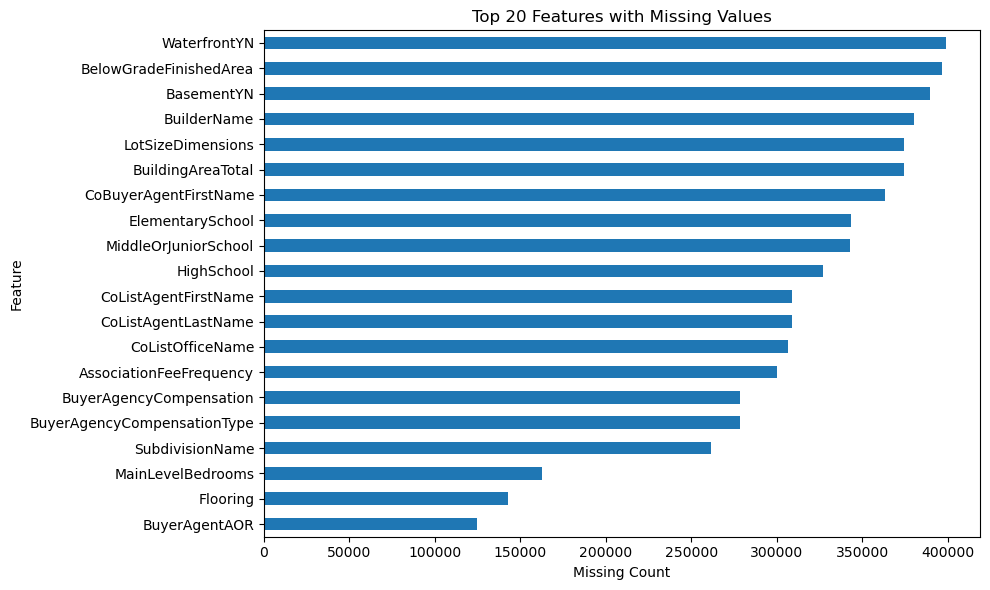

In [11]:
plt.figure(figsize = (10, 6))
missing.head(20).sort_values().plot.barh()
plt.title("Top 20 Features with Missing Values")
plt.xlabel("Missing Count")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## EDA

### 1. ClosePrice distribution

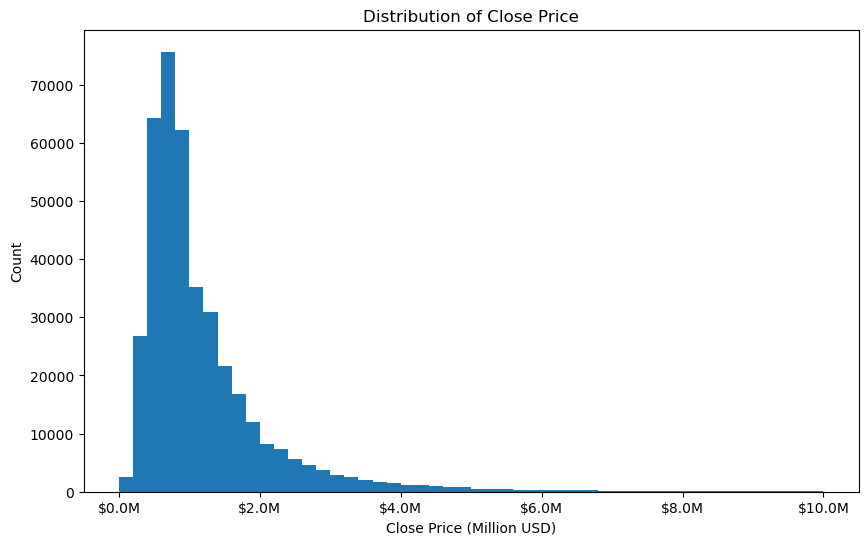

In [12]:
plt.figure(figsize = (10, 6))
plt.hist(df.loc[(df["ClosePrice"] > 0) & (df["ClosePrice"] <= 10_000_000), "ClosePrice"].dropna(), bins = 50)
plt.title("Distribution of Close Price")
plt.xlabel("Close Price (Million USD)")
plt.ylabel("Count")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M"))
plt.show()

Observation:

The ClosePrice distribution is highly right-skewed. 

Most residential properties were sold below $1 million, while a small number of luxury homes create a long right tail.

### 2. Log ClosePrice distribution

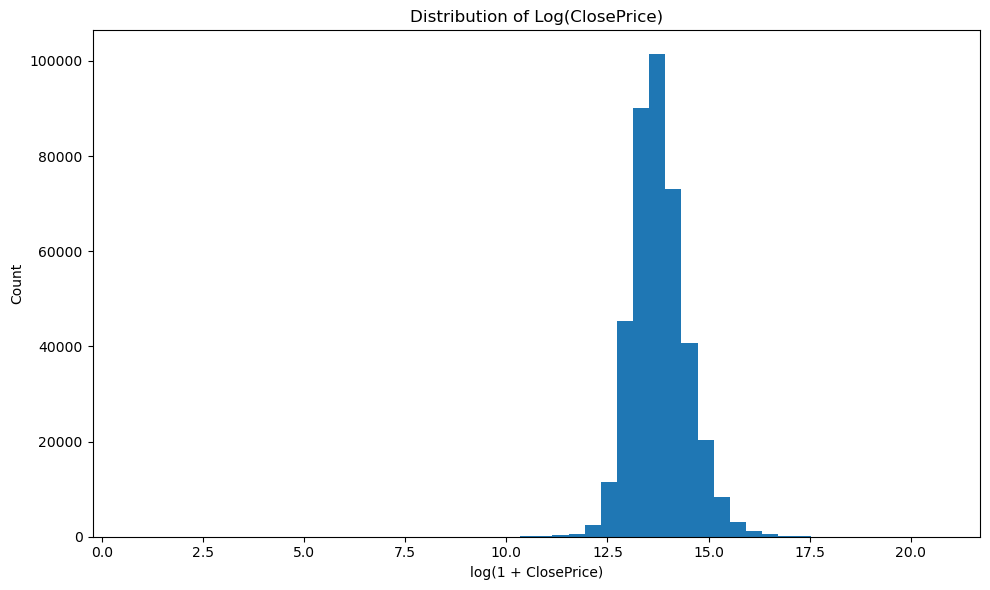

In [13]:
log_price = df.loc[df["ClosePrice"] > 0, "ClosePrice"].dropna()
plt.figure(figsize = (10, 6))
plt.hist(np.log1p(log_price), bins = 50)
plt.title("Distribution of Log(ClosePrice)")
plt.xlabel("log(1 + ClosePrice)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3. LivingArea distribution

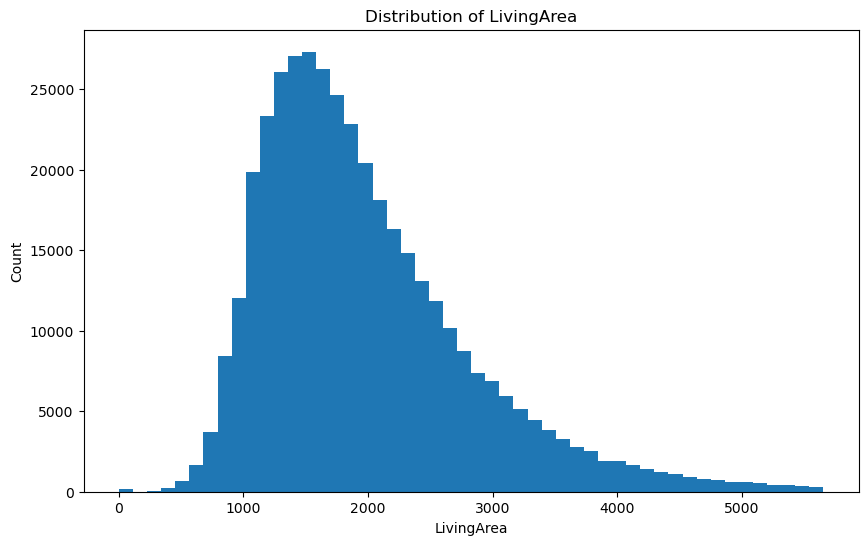

In [14]:
living_area_99 = df["LivingArea"].quantile(0.99)

plt.figure(figsize = (10, 6))
plt.hist(df.loc[df["LivingArea"] <= living_area_99, "LivingArea"].dropna(), bins = 50)
plt.title("Distribution of LivingArea")
plt.xlabel("LivingArea")
plt.ylabel("Count")
plt.ticklabel_format(style = "plain", axis = "x")
plt.show()

Observation:

LivingArea also exhibits a right-skewed distribution. 

Most homes are smaller than 3,000 square feet.

### 4. ClosePrice vs LivingArea scatter plot

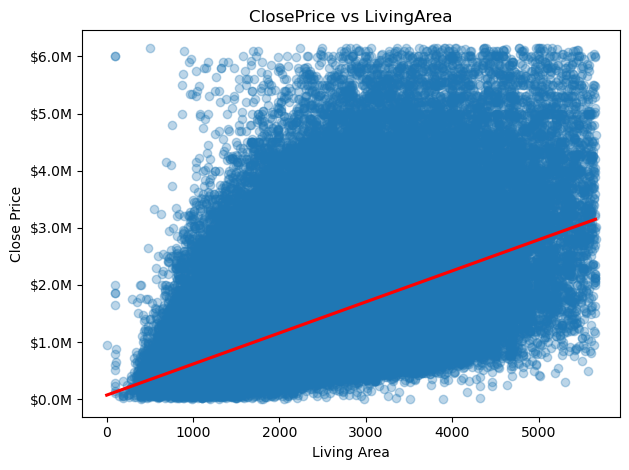

In [15]:
plot_df = df[["ClosePrice", "LivingArea"]].dropna()
# Remove zero cases
plot_df = plot_df[(plot_df["ClosePrice"] > 0) & (plot_df["LivingArea"] > 0)]
# Remove extreme outliers for better visualization
plot_df = plot_df[(plot_df["ClosePrice"] <= plot_df["ClosePrice"].quantile(0.99)) &\
(plot_df["LivingArea"] <= plot_df["LivingArea"].quantile(0.99))]
sns.regplot(x = "LivingArea", y = "ClosePrice", data = plot_df,\
            scatter_kws = {"alpha":0.3}, line_kws = {"color":"red"})
plt.title("ClosePrice vs LivingArea")
plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f}M"))
plt.tight_layout()
plt.show()

Observation:

There is a clear positive relationship between LivingArea and ClosePrice. 

Larger homes generally sell at higher prices, although price variability increases for larger properties.

### 5. BedroomsTotal count plot

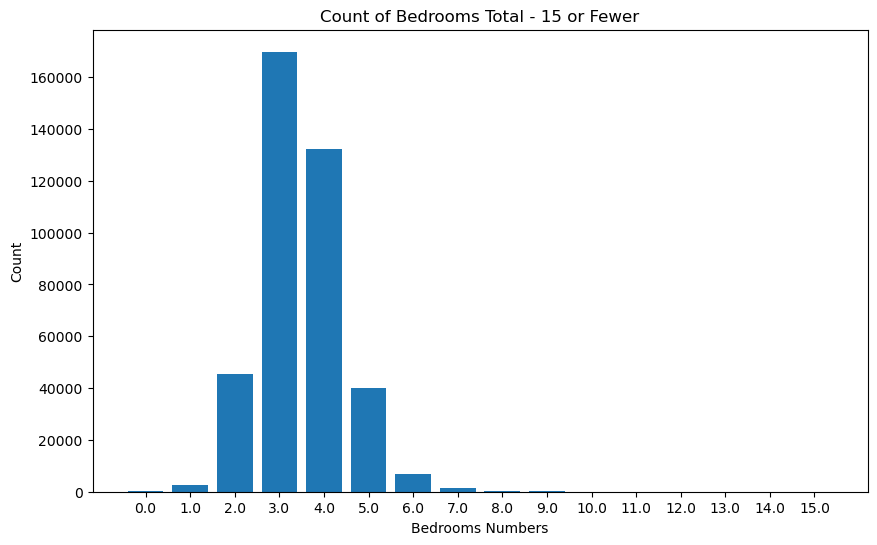

In [16]:
bedroom_df = df[(df["BedroomsTotal"].notna()) & (df["BedroomsTotal"] <= 15)]
bedroom_counts = bedroom_df["BedroomsTotal"].value_counts().sort_index()
plt.figure(figsize = (10, 6))
plt.bar(bedroom_counts.index.astype(str), bedroom_counts.values)
plt.title("Count of Bedrooms Total - 15 or Fewer")
plt.xlabel("Bedrooms Numbers")
plt.ylabel("Count")
plt.show()

### 6. BathroomsTotalInteger count plot

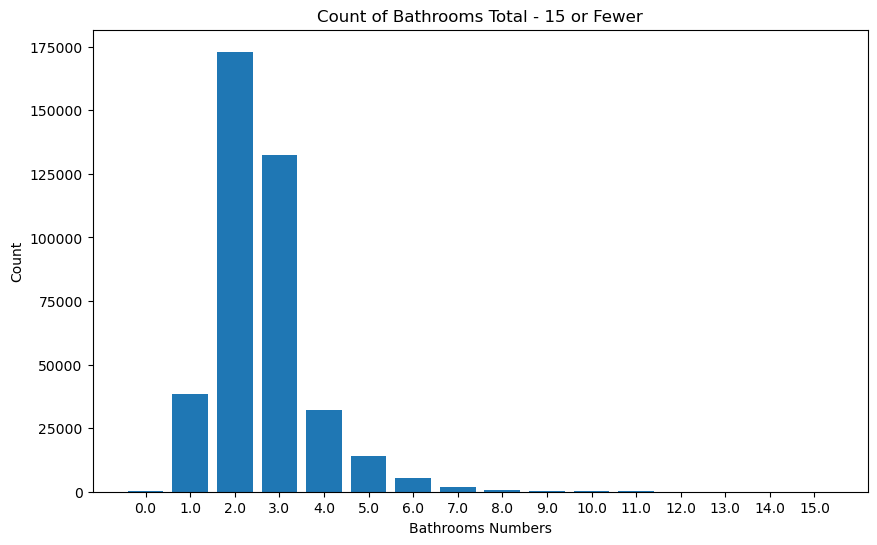

In [17]:
bathroom_df = df[(df["BathroomsTotalInteger"].notna()) & (df["BathroomsTotalInteger"] <= 15)]
bathroom_counts = bathroom_df["BathroomsTotalInteger"].value_counts().sort_index()
plt.figure(figsize = (10, 6))
plt.bar(bathroom_counts.index.astype(str), bathroom_counts.values)
plt.title("Count of Bathrooms Total - 15 or Fewer")
plt.xlabel("Bathrooms Numbers")
plt.ylabel("Count")
plt.show()

### 7. Top 20 cities by record count

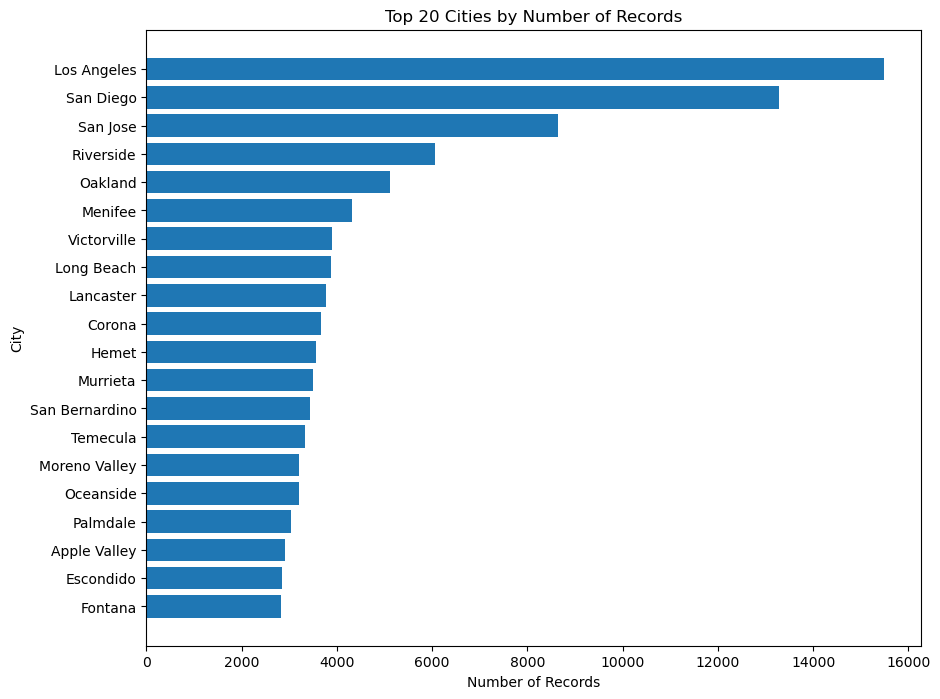

In [18]:
top_cities = df["City"].value_counts().head(20).sort_values()
plt.figure(figsize = (10, 8))
plt.barh(top_cities.index, top_cities.values)
plt.title("Top 20 Cities by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("City")
plt.show()

### 8. Median ClosePrice by top cities

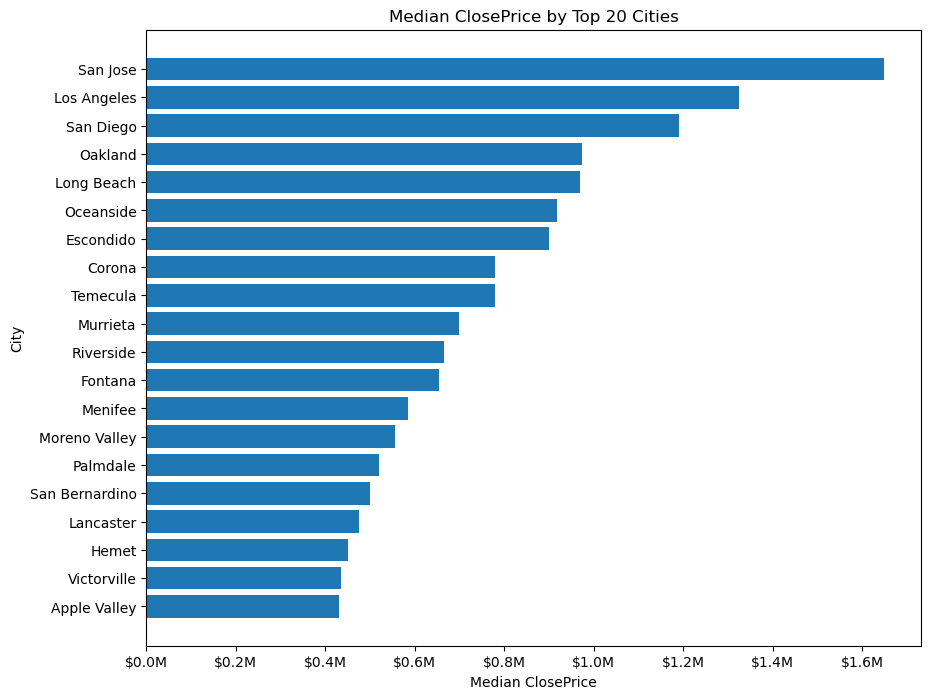

In [19]:
top_20_city_names = df["City"].value_counts().head(20).index
city_median_price = (df[df["City"].isin(top_20_city_names)].groupby("City")["ClosePrice"]\
                     .median().sort_values())
plt.figure(figsize = (10, 8))
plt.barh(city_median_price.index, city_median_price.values)
plt.title("Median ClosePrice by Top 20 Cities")
plt.xlabel("Median ClosePrice")
plt.ylabel("City")
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M"))
plt.show()

### 9. Monthly transaction count and median ClosePrice

In [20]:
df["CloseYearMonth"] = df["CloseDate"].dt.to_period("M").astype(str)
monthly_summary = df.groupby("CloseYearMonth")\
.agg(transaction_count = ("ClosePrice", "size"), median_close_price = ("ClosePrice", "median")).\
reset_index()
monthly_summary

,CloseYearMonth,transaction_count,median_close_price
0,2022-01,2313,700000.0
1,2022-02,1227,696560.0
2,2022-03,873,755000.0
3,2022-04,408,812325.0
4,2022-05,229,840000.0
5,2022-06,171,869000.0
6,2022-07,100,800000.0
7,2022-08,72,832500.0
8,2022-09,50,773500.0
9,2022-10,38,947500.0


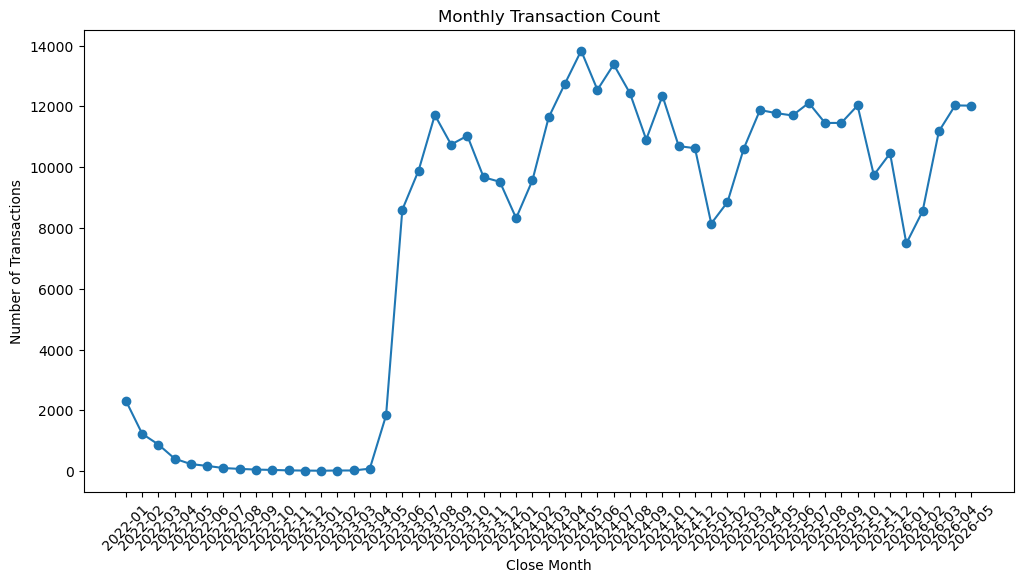

In [21]:
plt.figure(figsize = (12, 6))
plt.plot(monthly_summary["CloseYearMonth"], monthly_summary["transaction_count"], marker = "o")
plt.title("Monthly Transaction Count")
plt.xlabel("Close Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation = 45)
plt.show()

In [22]:
df_time = df[(df["CloseDate"].notna()) & (df["ClosePrice"].notna())].copy()
df_time["CloseYear"] = df_time["CloseDate"].dt.year
df_time["CloseMonth"] = df_time["CloseDate"].dt.month

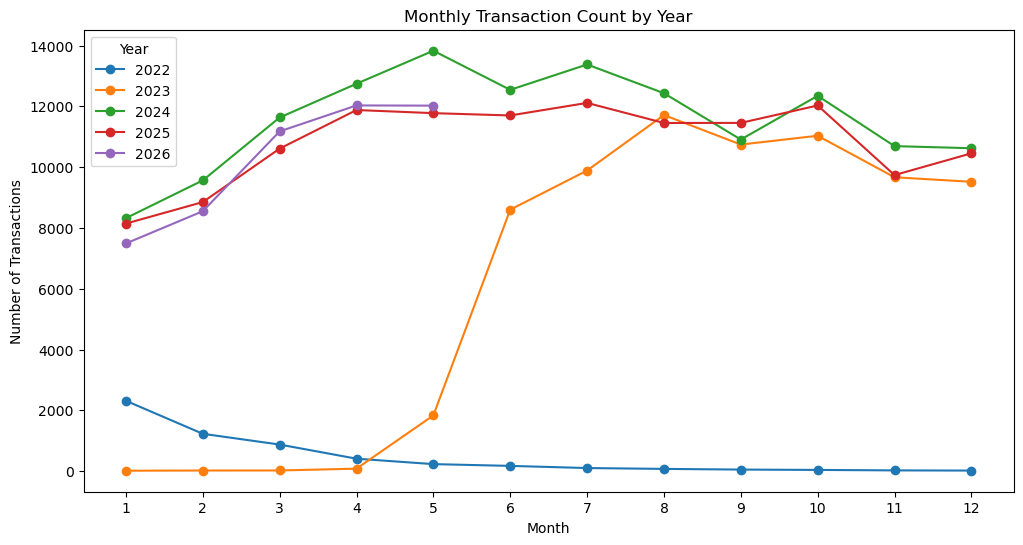

In [23]:
monthly_count = (df_time.groupby(["CloseYear", "CloseMonth"]).size().reset_index(name = "transaction_count"))
plt.figure(figsize = (12, 6))
for year in sorted(monthly_count["CloseYear"].unique()):
    year_data = monthly_count[monthly_count["CloseYear"] == year]
    plt.plot(
        year_data["CloseMonth"],
        year_data["transaction_count"],
        marker = "o",
        label = str(year)
    )
plt.title("Monthly Transaction Count by Year")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(range(1, 13))
plt.legend(title = "Year")
plt.show()

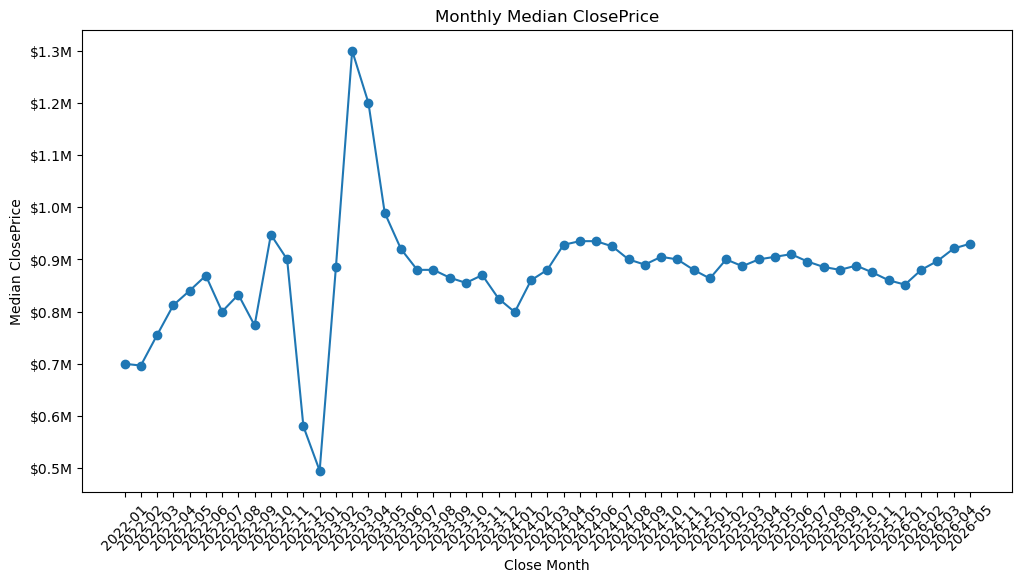

In [24]:
plt.figure(figsize = (12, 6))
plt.plot(monthly_summary["CloseYearMonth"], monthly_summary["median_close_price"], marker = "o")
plt.title("Monthly Median ClosePrice")
plt.xlabel("Close Month")
plt.ylabel("Median ClosePrice")
plt.xticks(rotation = 45)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f}M"))
plt.show()

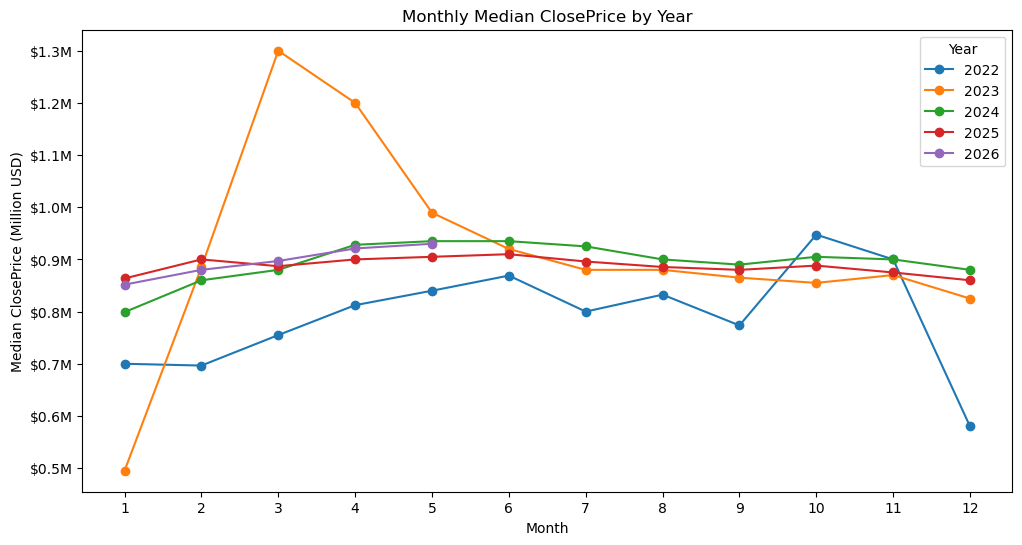

In [25]:
monthly_median_price = (df_time.groupby(["CloseYear", "CloseMonth"])["ClosePrice"].median()\
                        .reset_index(name = "median_close_price"))
plt.figure(figsize=(12, 6))
for year in sorted(monthly_median_price["CloseYear"].unique()):
    year_data = monthly_median_price[monthly_median_price["CloseYear"] == year]
    plt.plot(
        year_data["CloseMonth"],
        year_data["median_close_price"],
        marker = "o",
        label = str(year)
    )
plt.title("Monthly Median ClosePrice by Year")
plt.xlabel("Month")
plt.ylabel("Median ClosePrice (Million USD)")
plt.xticks(range(1, 13))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f}M"))
plt.legend(title="Year")
plt.show()

Observation:

Transaction volume decreased during winter months and increased during spring and summer.

### 10. Correlation Heatmap

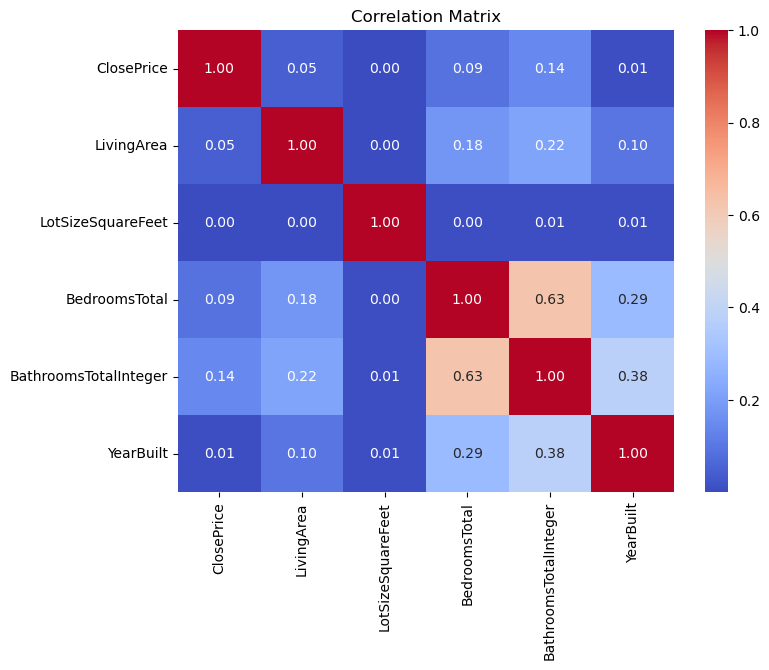

In [26]:
numeric_cols = ["ClosePrice", "LivingArea", "LotSizeSquareFeet", "BedroomsTotal",\
                "BathroomsTotalInteger", "YearBuilt"]
corr = df[numeric_cols].corr()
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

### 11. Year Built Distribution

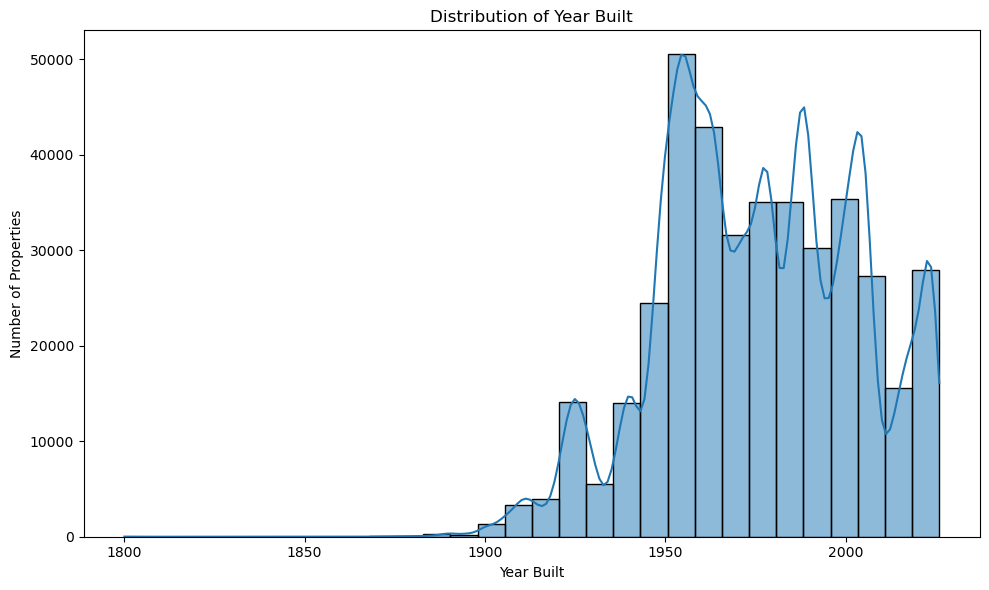

In [27]:
year_built = df["YearBuilt"].dropna()
year_built = year_built[(year_built >= 1800) & (year_built <= 2026)]
plt.figure(figsize = (10, 6))
sns.histplot(year_built, bins = 30, kde = True)
plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

Observation:

Most properties in the dataset were built after 1950, with a large concentration between 1950 and 2000. 

A small number of older properties appear before 1900 and may require additional review during preprocessing.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship